# Exploratory Data Visualization

In [142]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

df = pd.read_csv("Sleep_health_and_lifestyle_dataset.csv")
df.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


### Fix some data problem
- BMI: Merge normal& normal weight, obese with overweight
- Sleep disorder: NaN to None

In [143]:
df["BMI Category"] = df["BMI Category"].replace({
    "Normal": "Normal",
    "Normal Weight": "Normal",
    "Obese": "Overweight",
    "Overweight": "Overweight"
})

df["Sleep Disorder"] = df["Sleep Disorder"].fillna("None").replace({
    "none": "None",
    "NONE": "None",
    "": "None",
    " ": "None"
})


## 1. Basic Distributions of Key Variables
- We first examine the distribution of sleep duration, sleep quality, stress, and physical activity.

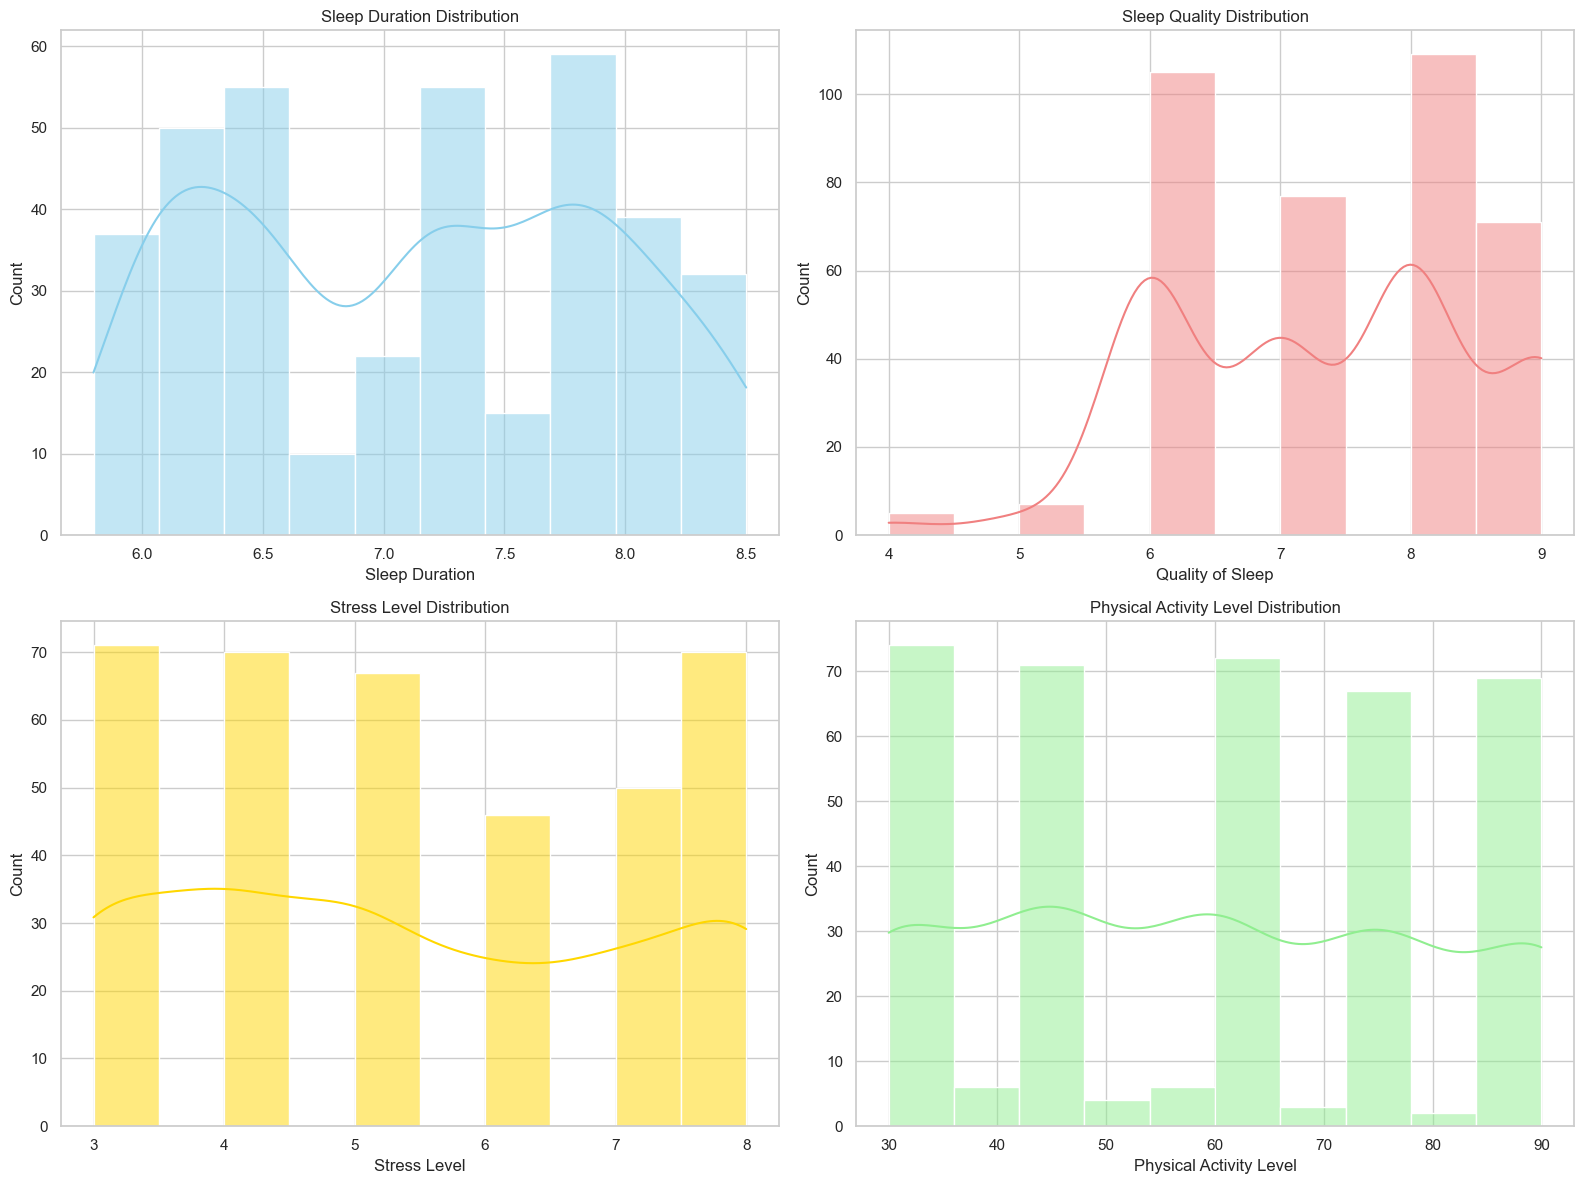

In [144]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

sns.histplot(df["Sleep Duration"], kde=True, ax=axes[0,0], color="skyblue")
axes[0,0].set_title("Sleep Duration Distribution")

sns.histplot(df["Quality of Sleep"], kde=True, ax=axes[0,1], color="lightcoral")
axes[0,1].set_title("Sleep Quality Distribution")

sns.histplot(df["Stress Level"], kde=True, ax=axes[1,0], color="gold")
axes[1,0].set_title("Stress Level Distribution")

sns.histplot(df["Physical Activity Level"], kde=True, ax=axes[1,1], color="lightgreen")
axes[1,1].set_title("Physical Activity Level Distribution")

plt.tight_layout()
plt.show()

The distributions of sleep duration, sleep quality, stress level, and physical activity show that most values fall in normal, expected ranges.

- **Sleep Duration** is mostly between 6–8 hours, suggesting that most participants get a reasonable amount of sleep.
- **Sleep Quality** tends to cluster between 6 and 9, indicating many people feel they sleep fairly well.
- **Stress Level** varies more widely, but many individuals report mid-to-high stress.
- **Physical Activity** ranges from about 30 to 80 minutes per day, showing that the sample is generally active, with no extreme outliers.

Overall, these distributions suggest a fairly healthy population with balanced lifestyle characteristics.


In [145]:
## 2. Correlation Heatmap

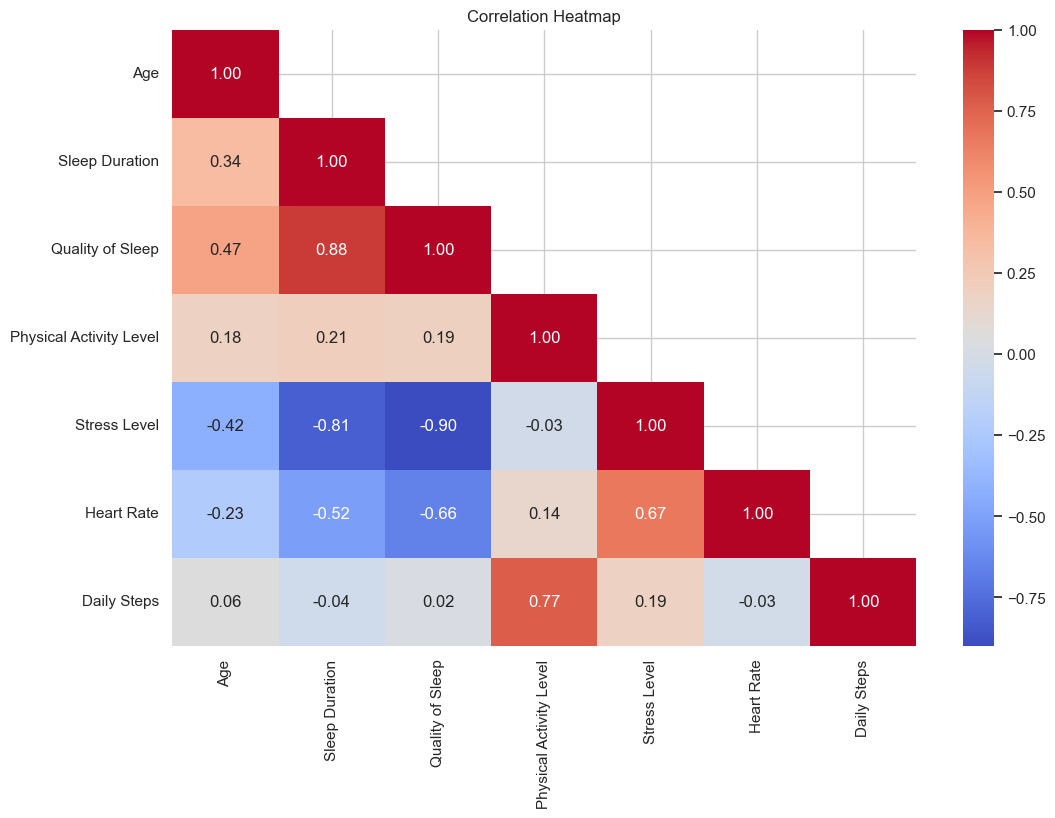

In [146]:
numeric_cols = [
    "Age",
    "Sleep Duration",
    "Quality of Sleep",
    "Physical Activity Level",
    "Stress Level",
    "Heart Rate",
    "Daily Steps"
]

corr = df[numeric_cols].corr()

# --- Create triangle mask ---
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

plt.figure(figsize=(12, 8))
sns.heatmap(
    corr, 
    mask=mask,
    annot=True, 
    cmap="coolwarm", 
    fmt=".2f"
)
plt.title("Correlation Heatmap")
plt.show()


## 3. Sleep Quality Across Occupations

In [147]:
df["Occupation"].value_counts().reset_index()


,Occupation,count
0,Nurse,73
1,Doctor,71
2,Engineer,63
3,Lawyer,47
4,Teacher,40
5,Accountant,37
6,Salesperson,32
7,Scientist,4
8,Software Engineer,4
9,Sales Representative,2


Some occupations does not have enough data, drop them.

In [148]:
min_count = 10

# Find occupations that meet the threshold
valid_occ = df['Occupation'].value_counts()
valid_occ = valid_occ[valid_occ >= min_count].index

# Filter the DataFrame
df = df[df['Occupation'].isin(valid_occ)]
df["Occupation"].value_counts().reset_index()

,Occupation,count
0,Nurse,73
1,Doctor,71
2,Engineer,63
3,Lawyer,47
4,Teacher,40
5,Accountant,37
6,Salesperson,32


Occupation & Sleep Quality

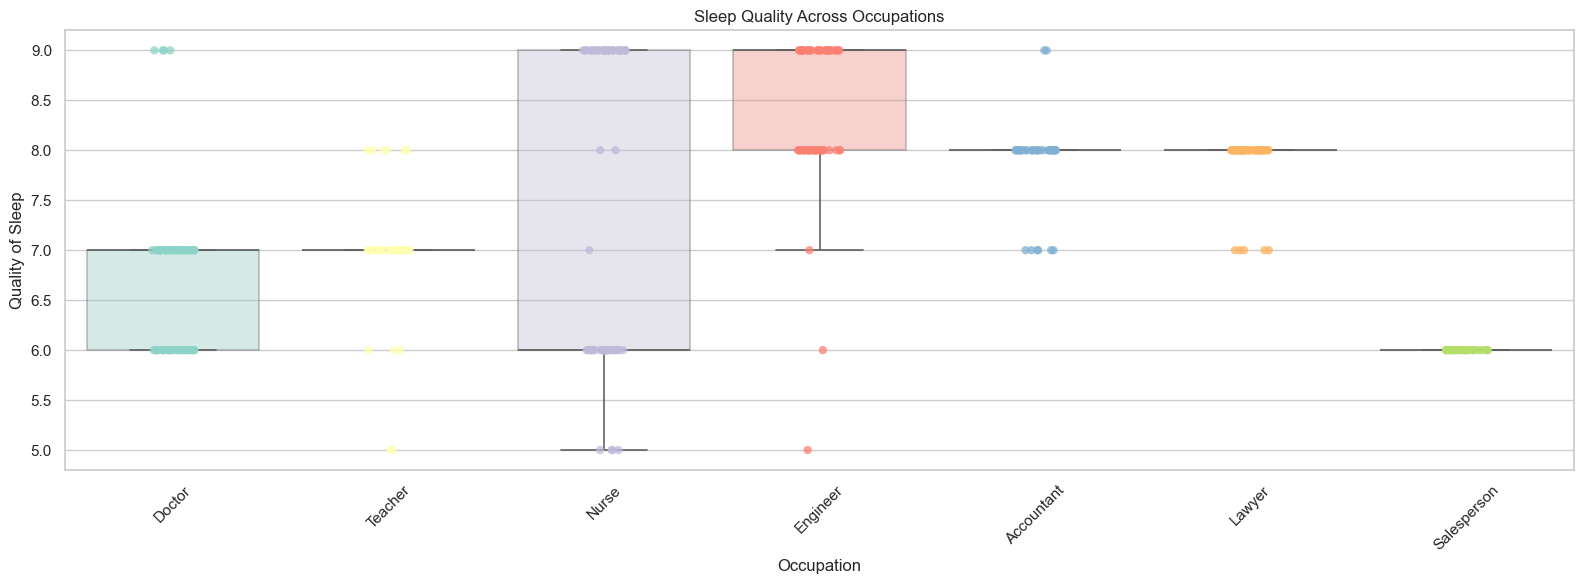

In [149]:
top_occ = df["Occupation"].value_counts().head(10).index

plt.figure(figsize=(16, 6))

# Generate a color palette matching the number of occupations
occupations = df["Occupation"].unique()
palette = sns.color_palette("Set3", n_colors=len(occupations))
color_map = dict(zip(occupations, palette))

# Boxplot with matching colors
sns.boxplot(
    data=df,
    x="Occupation",
    y="Quality of Sleep",
    hue="Occupation",
    palette=color_map,
    dodge=False,
    boxprops={"alpha": 0.4},    # slightly transparent
    linewidth=1.2,
    showfliers=False,          # hide outliers to avoid clutter
    legend=False
)

# Overlay stripplot (raw points)
sns.stripplot(
    data=df,
    x="Occupation",
    y="Quality of Sleep",
    hue="Occupation",
    palette=color_map,
    dodge=False,
    alpha=0.75,
    size=6,
    legend=False
)

plt.xticks(rotation=45)
plt.title("Sleep Quality Across Occupations")
plt.tight_layout()
plt.show()



Sleep quality varies across job types:

- Healthcare jobs (Nurse, Doctor) show a moderate level of sleep quality, with noticeable variation.
- Jobs like Engineer and Accountant tend to have slightly more consistent and higher sleep quality.
- Occupations with very few samples (e.g., Manager, Sales Representative) are harder to interpret.

This suggests that occupation-related routine or stress levels may influence sleep quality, but sample size differences should be considered.

## 3. Group Analysis
We group occupations based on sleep quality patterns as hypothesized:
- **Group A (Stable)**: Accountant, Lawyer (High and stable sleep quality)
- **Group B (Variable)**: Nurse, Doctor (Variable sleep quality)
- **Group C (Poor)**: Salesperson, Sales Representative (Lower sleep quality)

We will verify these patterns and analyze the potential causes.

C:\Users\chen-\AppData\Local\Temp\ipykernel_41860\693252966.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Occupation Group', y='Quality of Sleep', data=df_groups, palette='coolwarm', order=['Group A (Stable)', 'Group B (Variable)', 'Group C (Poor)'])


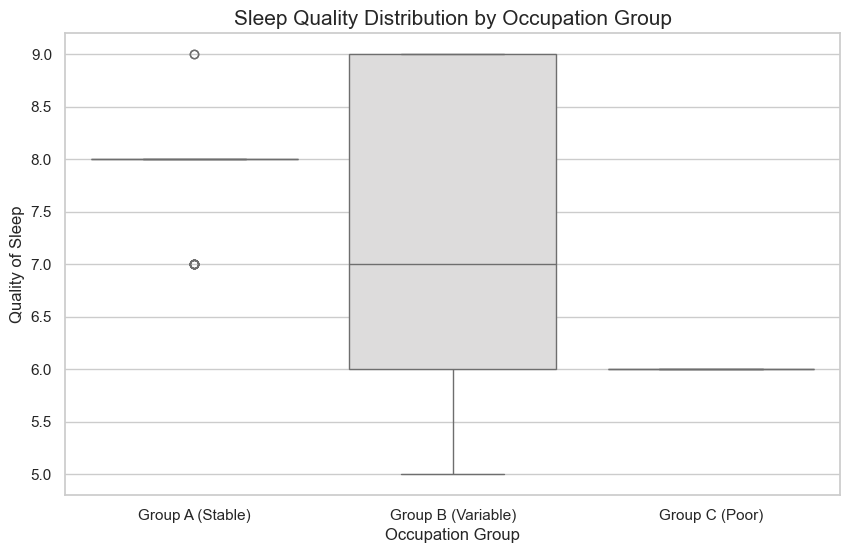

                        mean      std  count
Occupation Group                            
Group A (Stable)    7.892857  0.38080     84
Group B (Variable)  7.013889  1.27365    144
Group C (Poor)      6.000000  0.00000     32


In [150]:
# Define Occupation Groups
def get_occupation_group(occupation):
    if occupation in ['Accountant', 'Lawyer']:
        return 'Group A (Stable)'
    elif occupation in ['Nurse', 'Doctor']:
        return 'Group B (Variable)'
    elif occupation in ['Salesperson']:  # Removed Sales Representative
        return 'Group C (Poor)'
    else:
        return 'Other'

df['Occupation Group'] = df['Occupation'].apply(get_occupation_group)

# Filter for analysis (exclude 'Other' if needed, but keeping for context might be good. Let's focus on the 3 groups)
df_groups = df[df['Occupation Group'] != 'Other'].copy()

# Verify Sleep Quality Distribution by Group
plt.figure(figsize=(10, 6))
sns.boxplot(x='Occupation Group', y='Quality of Sleep', data=df_groups, palette='coolwarm', order=['Group A (Stable)', 'Group B (Variable)', 'Group C (Poor)'])
plt.title('Sleep Quality Distribution by Occupation Group', fontsize=15)
plt.show()

# Calculate Variance/Std Dev to quantify stability
group_stats = df_groups.groupby('Occupation Group')['Quality of Sleep'].agg(['mean', 'std', 'count'])
print(group_stats)

### Stress Level

C:\Users\chen-\AppData\Local\Temp\ipykernel_41860\1557096222.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Occupation Group', y='Stress Level', data=df_groups, palette='coolwarm', order=['Group A (Stable)', 'Group B (Variable)', 'Group C (Poor)'])


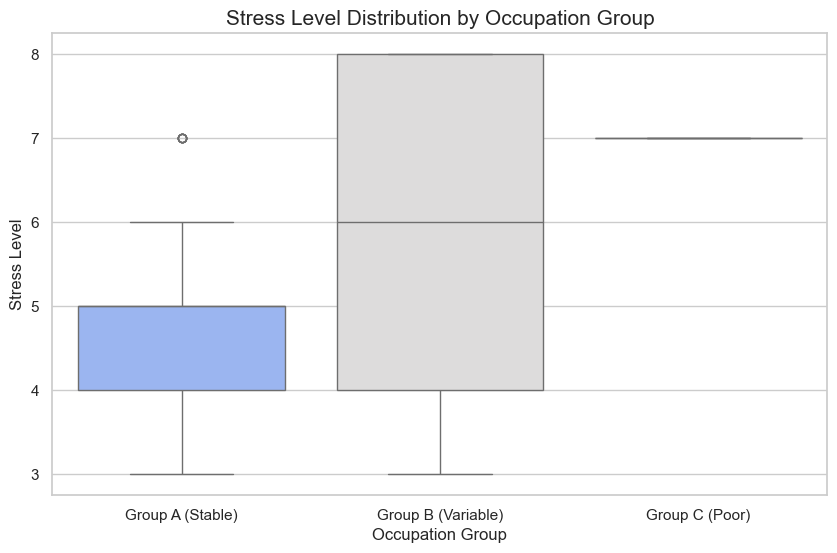

In [151]:
# Stress Level by Group
plt.figure(figsize=(10, 6))
sns.boxplot(x='Occupation Group', y='Stress Level', data=df_groups, palette='coolwarm', order=['Group A (Stable)', 'Group B (Variable)', 'Group C (Poor)'])
plt.title('Stress Level Distribution by Occupation Group', fontsize=15)
plt.show()



### Physical activities

C:\Users\chen-\AppData\Local\Temp\ipykernel_41860\1833329223.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Occupation Group', y='Physical Activity Level', data=df_groups, palette='coolwarm', order=['Group A (Stable)', 'Group B (Variable)', 'Group C (Poor)'])


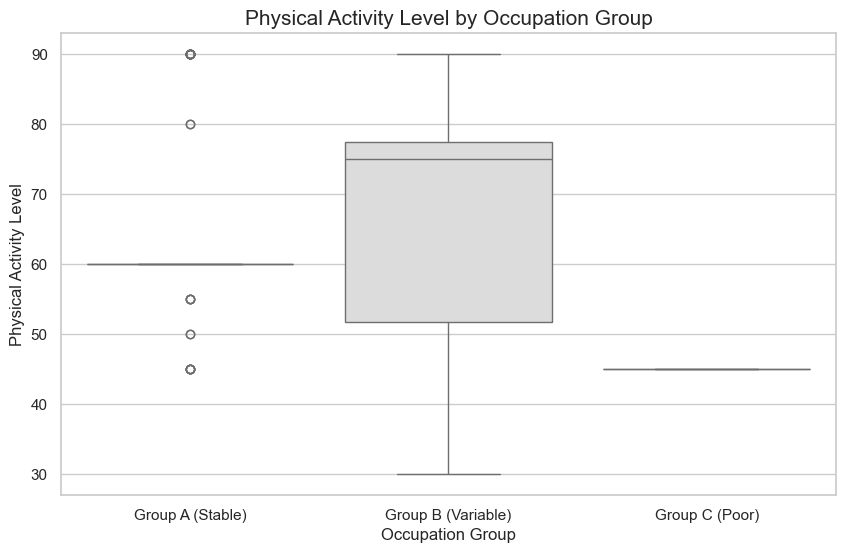

In [152]:
# Physical Activity by Group
plt.figure(figsize=(10, 6))
sns.boxplot(x='Occupation Group', y='Physical Activity Level', data=df_groups, palette='coolwarm', order=['Group A (Stable)', 'Group B (Variable)', 'Group C (Poor)'])
plt.title('Physical Activity Level by Occupation Group', fontsize=15)
plt.show()

### BMI

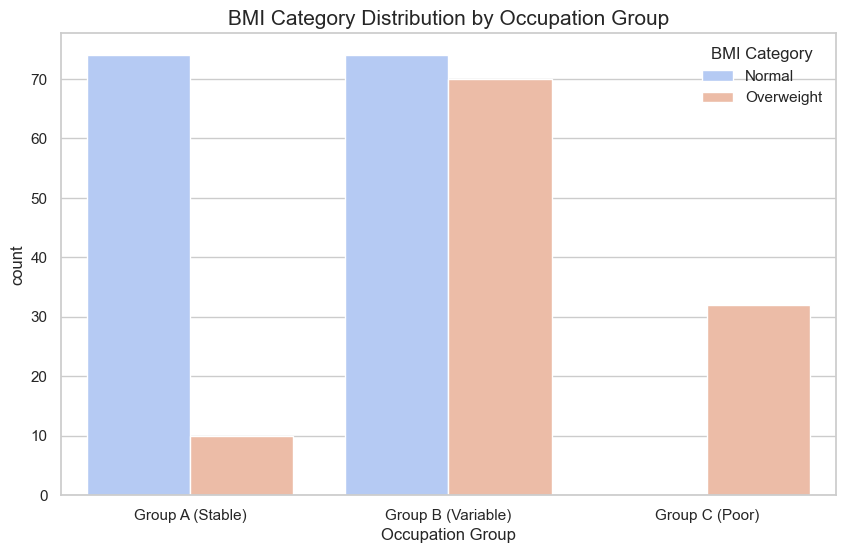

In [153]:
# BMI Category by Group
plt.figure(figsize=(10, 6))
sns.countplot(x='Occupation Group', hue='BMI Category', data=df_groups, palette='coolwarm', order=['Group A (Stable)', 'Group B (Variable)', 'Group C (Poor)'])
plt.title('BMI Category Distribution by Occupation Group', fontsize=15)
plt.legend(title='BMI Category', loc='upper right')
plt.show()

### Sleep Disorder

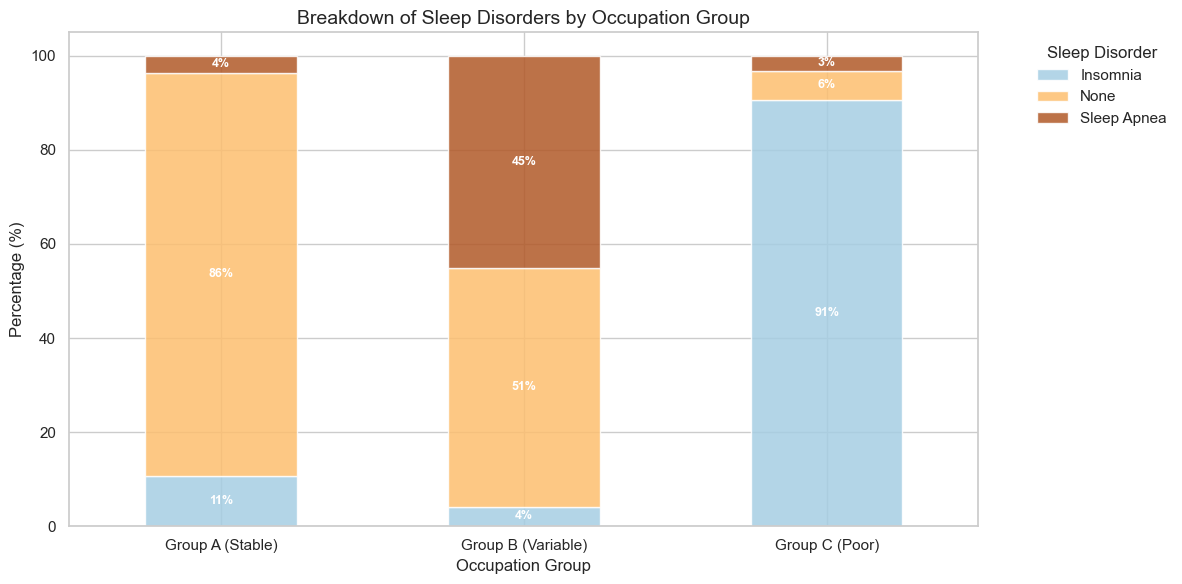

In [154]:
# Calculate percentage of each sleep disorder within each occupation group
group_disorder = pd.crosstab(
    df_groups['Occupation Group'], 
    df_groups['Sleep Disorder'], 
    normalize='index'
) * 100

# Ensure group order
group_disorder = group_disorder.loc[
    ['Group A (Stable)', 'Group B (Variable)', 'Group C (Poor)']
]

# Plotting
ax = group_disorder.plot(
    kind='bar',
    stacked=True,
    figsize=(12, 6),
    colormap='Paired',
    alpha=0.85
)

plt.title('Breakdown of Sleep Disorders by Occupation Group', fontsize=14)
plt.xlabel('Occupation Group')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=0)
plt.legend(title='Sleep Disorder', bbox_to_anchor=(1.05, 1), loc='upper left')

# Add percentage labels
for c in ax.containers:
    ax.bar_label(c, fmt='%.0f%%', label_type='center', color='white', fontsize=9, weight='bold')

plt.tight_layout()
plt.show()


Or Another version by sinuo in the chat

![alt text](sdocpg.webp)

### Lift style Radar Plot

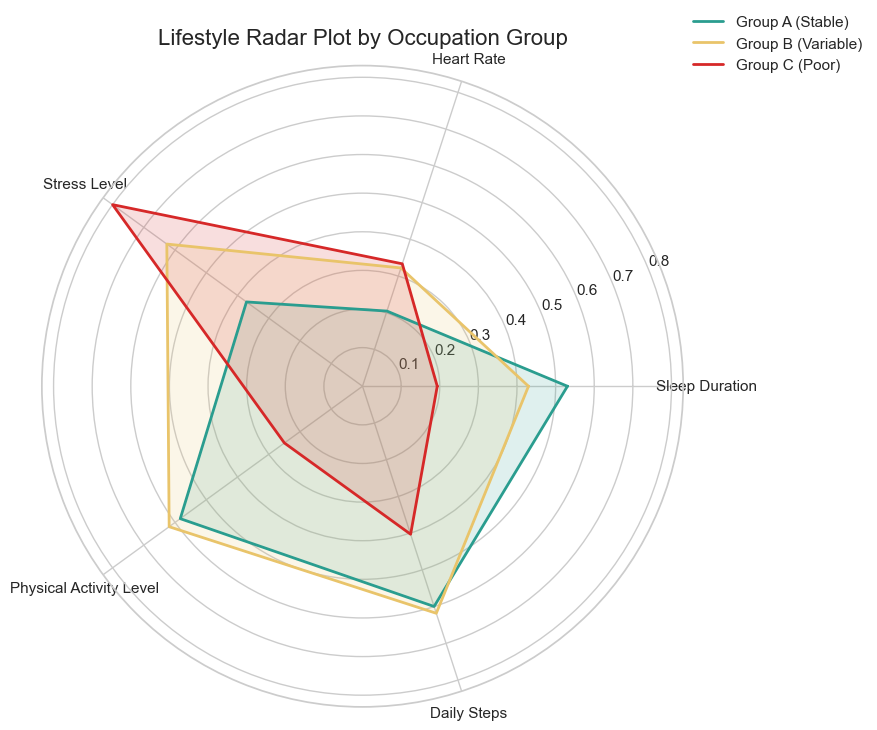

In [155]:
radar_cols = [
    "Sleep Duration",
    "Heart Rate",# or Quality of Sleep
    "Stress Level",
    "Physical Activity Level",
    "Daily Steps"
]

df_norm = df.copy()
for col in radar_cols:
    df_norm[col] = (df_norm[col] - df_norm[col].min()) / (df_norm[col].max() - df_norm[col].min())

# Use only the 3 occupation groups (ignore "Other")
df_groups = df_norm[df_norm["Occupation Group"] != "Other"].copy()

# Group by Occupation Group
grouped = (
    df_groups.groupby("Occupation Group")[radar_cols]
    .mean()
    .loc[["Group A (Stable)", "Group B (Variable)", "Group C (Poor)"]]  # ensure correct order
)

# Radar chart setup
labels = radar_cols
angles = np.linspace(0, 2*np.pi, len(labels), endpoint=False).tolist()
angles += angles[:1]

fig = plt.figure(figsize=(9, 9))
ax = plt.subplot(111, polar=True)

# Optional color palette
colors = {
    "Group A (Stable)": "#2a9d8f",
    "Group B (Variable)": "#e9c46a",
    "Group C (Poor)": "#d62828",
}

# Plot each occupation group
for group in grouped.index:
    values = grouped.loc[group].tolist()
    values += values[:1]

    ax.plot(angles, values, linewidth=2, label=group, color=colors.get(group, None))
    ax.fill(angles, values, alpha=0.15, color=colors.get(group, None))

# Final formatting
plt.xticks(angles[:-1], labels)
plt.title("Lifestyle Radar Plot by Occupation Group", fontsize=16)
plt.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.show()

###  3D Cluster

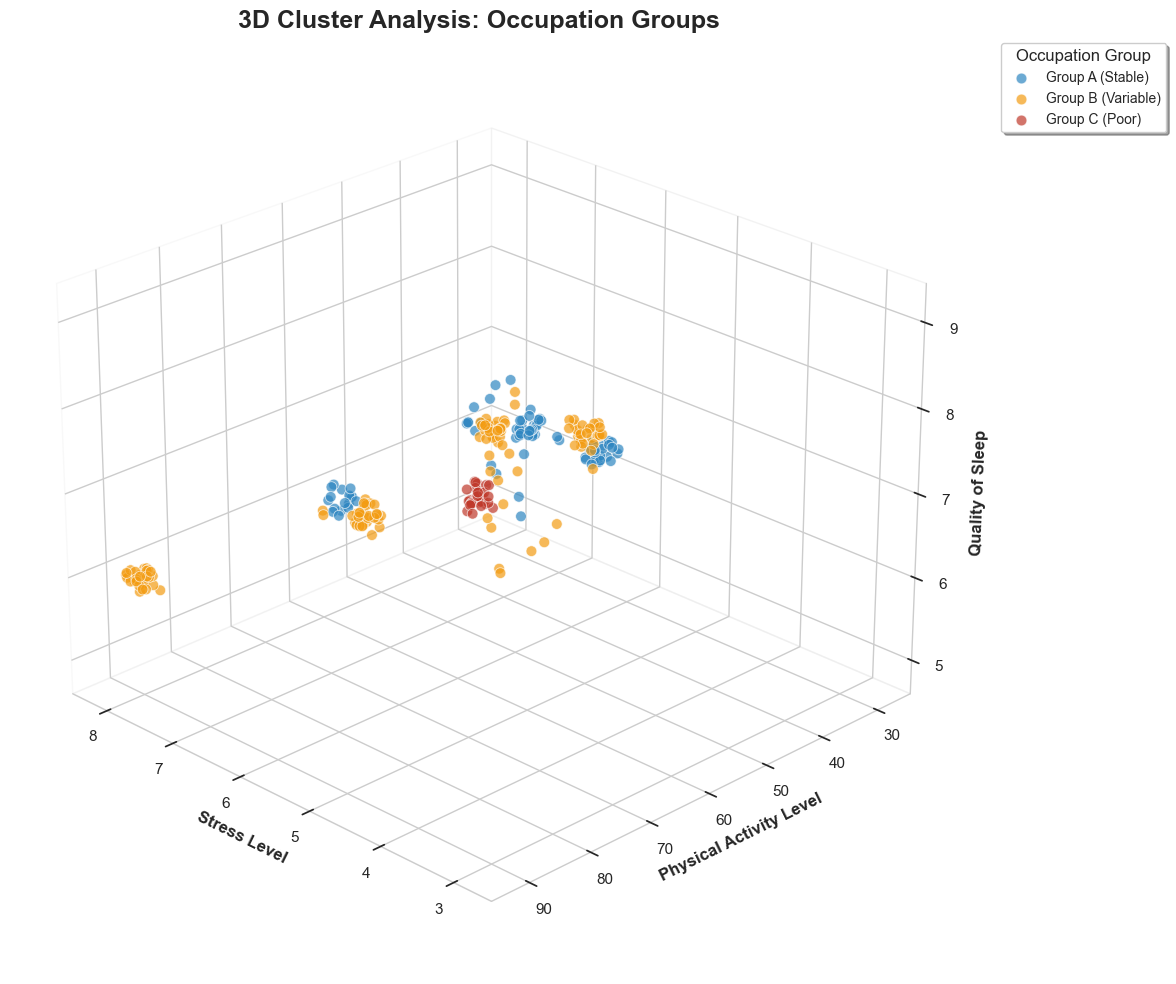

In [156]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import numpy as np

plt.style.use('seaborn-v0_8-whitegrid')

# Use only RAW data (important)
df_raw_groups = df[df['Occupation Group'] != 'Other'].copy()

fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

colors = {
    'Group A (Stable)': '#2E86C1',
    'Group B (Variable)': '#F39C12',
    'Group C (Poor)': '#C0392B'
}

def add_jitter(arr, amount=0.2):
    return arr + np.random.uniform(-amount, amount, size=len(arr))

for group, color in colors.items():
    subset = df_raw_groups[df_raw_groups['Occupation Group'] == group]

    # 🔥 RAW VALUES — NOT NORMALIZED
    x = subset['Stress Level']
    y = subset['Physical Activity Level']
    z = subset['Quality of Sleep']

    # Apply jitter for visibility
    x_j = add_jitter(x, 0.15)
    y_j = add_jitter(y, 1.5)
    z_j = add_jitter(z, 0.15)

    ax.scatter(
        x_j, y_j, z_j,
        c=color, label=group,
        s=60, alpha=0.7, edgecolors='white', linewidth=0.6
    )

# Labels
ax.set_xlabel('Stress Level', fontsize=12, fontweight='bold')
ax.set_ylabel('Physical Activity Level', fontsize=12, fontweight='bold')
ax.set_zlabel('Quality of Sleep', fontsize=12, fontweight='bold')
ax.set_title('3D Cluster Analysis: Occupation Groups', fontsize=18, fontweight='bold')

# Clean grid
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False
ax.grid(True, linestyle='--', alpha=0.4)

# Legend
ax.legend(
    title='Occupation Group',
    title_fontsize=12,
    fontsize=10,
    frameon=True,
    shadow=True,
    loc='upper left',
    bbox_to_anchor=(1.05, 1)
)

ax.view_init(elev=25, azim=135)
plt.tight_layout()
plt.show()


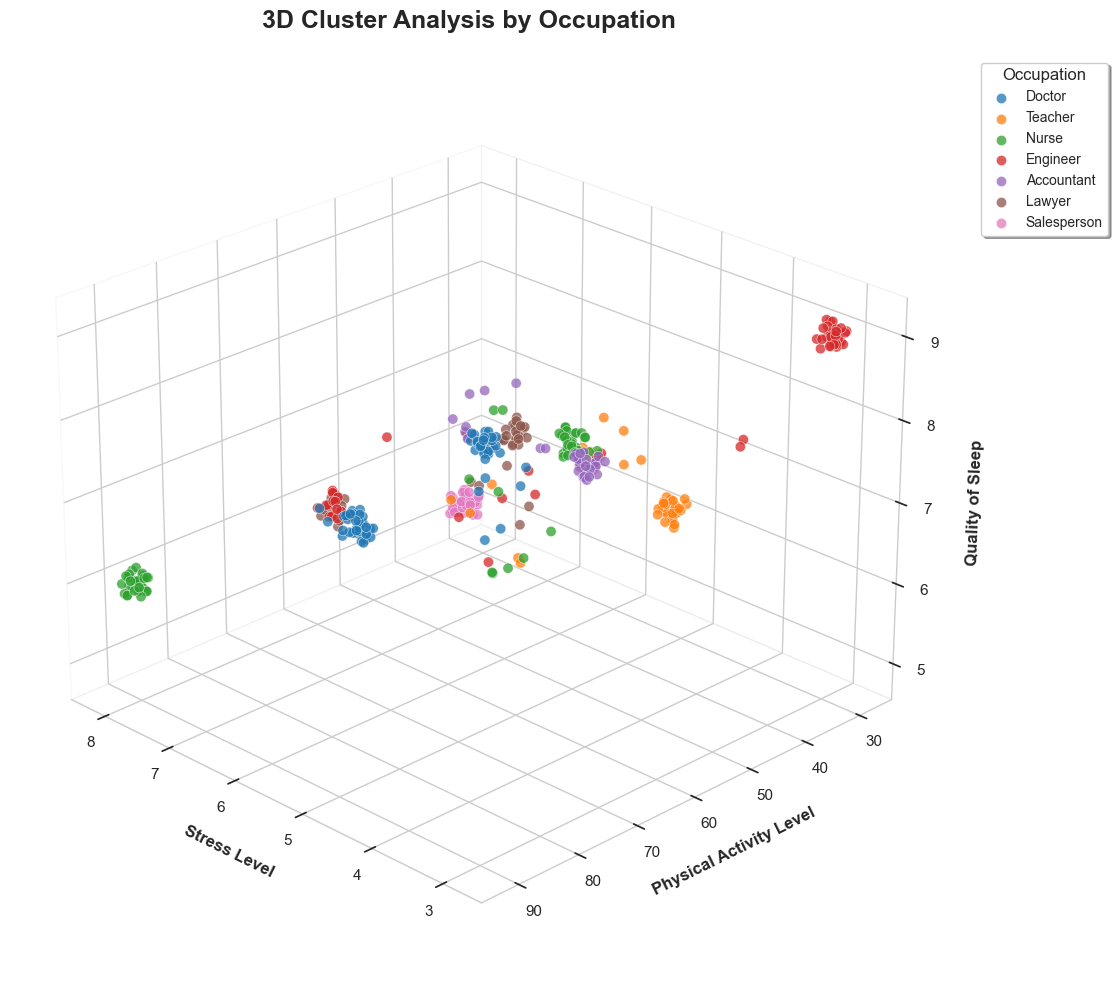

In [157]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import numpy as np

plt.style.use('seaborn-v0_8-whitegrid')

fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

# Unique occupations
occupations = df['Occupation'].unique()

# Automatically assign distinct colors from a colormap
cmap = plt.get_cmap('tab10')   # good for categorical values
color_map = {occ: cmap(i % 10) for i, occ in enumerate(occupations)}

# Function to add jitter
def add_jitter(arr, amount=0.2):
    return arr + np.random.uniform(-amount, amount, size=len(arr))

# Plot each occupation separately
for occ in occupations:
    subset = df[df['Occupation'] == occ]

    x_jittered = add_jitter(subset['Stress Level'], 0.15)
    y_jittered = add_jitter(subset['Physical Activity Level'], 1.5)
    z_jittered = add_jitter(subset['Quality of Sleep'], 0.15)

    ax.scatter(
        x_jittered,
        y_jittered,
        z_jittered,
        c=[color_map[occ]],
        label=occ,
        s=55,
        alpha=0.75,
        edgecolors='w',
        linewidth=0.4
    )

# Labels and Title
ax.set_xlabel('Stress Level', fontsize=12, labelpad=10, fontweight='bold')
ax.set_ylabel('Physical Activity Level', fontsize=12, labelpad=10, fontweight='bold')
ax.set_zlabel('Quality of Sleep', fontsize=12, labelpad=10, fontweight='bold')
ax.set_title('3D Cluster Analysis by Occupation', fontsize=18, fontweight='bold', pad=20)

# Clean background
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False
ax.grid(True, linestyle='--', alpha=0.5)

# Legend on side
ax.legend(
    title='Occupation',
    title_fontsize=12,
    fontsize=10,
    loc='upper left',
    bbox_to_anchor=(1.05, 1),
    frameon=True,
    shadow=True
)

# Better viewing angle
ax.view_init(elev=25, azim=135)

plt.tight_layout()
plt.show()
